## 1. Load and Filter Data
This section loads the original dataset and filters sentences where the 'fuel' column has a negative sentiment.

In [1]:
import pandas as pd
import os
import nltk
# Load the dataset

##TODO## : isikan path dataset kalian di sini ##
file_path = os.path.join('data', 'train_preprocess.csv')

df = pd.read_csv(file_path)
# Filter sentences where fuel is negative
negative_fuel_df = df[df['fuel'] == 'negative'][['sentence']]
# Display a sample of the filtered dataset
print(negative_fuel_df.head())

## TODO: isikan path direktori untuk menyimpan nltk data di sini ##
nltk_data_dir = os.path.join('data', 'nltk_data')

os.makedirs(nltk_data_dir, exist_ok=True)
# Download stopwords to the specified directory
nltk.download('stopwords', download_dir=nltk_data_dir)

                                              sentence
1    Avanza kenapa jadi boros bensin begini dah ah....
38   dari segi kenyamanan cortez oke lah, tapi baha...
113  kalau sudah di atas 120 km / jam boros banget ...
116          Rush konde konsumsi BBM yang tetap irit .
124  pengalaman saya punya avanza bahan bakar nya l...


[nltk_data] Downloading package stopwords to data/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 2. Text Summarization
This section performs text summarization using the TextRank algorithm 

In [2]:
import spacy
import networkx as nx
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

# Load the SpaCy Indonesian model
nlp = spacy.blank('id')

nlp.add_pipe('sentencizer')


def custom_tokenizer(text):
    return [token.text for token in nlp(text)]


# Remove stopwords and non-meaningful tokens
def enhanced_tokenizer(text):
    from nltk.corpus import stopwords
    try:
        stop_words = set(stopwords.words('indonesian'))
    except:
        import nltk
        nltk.download('stopwords')
        stop_words = set(stopwords.words('indonesian'))
    tokens = custom_tokenizer(text)
    tokens = [
        token for token in tokens if token not in stop_words and len(token) > 2]
    return tokens

def textrank_summarizer(text, num_sentences=5):
    # Tokenize sentences
    doc = nlp(text)
    sentences = [sent.text for sent in doc.sents]

    # Convert sentences to TF-IDF vectors
    ## TODO:inisialisasi TfidfVectorizer dengan menggunakan enhanced tokenizer yang sudah dibuat ##
    vectorizer = TfidfVectorizer(tokenizer=enhanced_tokenizer)
    ## TODO:hitung tf-idf matrix untuk kalimat menggunakan vectorizer ##
    tfidf_matrix = vectorizer.fit_transform(sentences)

    # Compute cosine similarity matrix
    ## TODO: hitung cosine similarity antara kalimat menggunakan tfidf_matrix ##   
    similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)

    # Build the graph and rank sentences
    nx_graph = nx.from_numpy_array(similarity_matrix)
    scores = nx.pagerank(nx_graph)

    # Rank sentences by their TextRank score
    ranked_sentences = sorted(((scores[i], s) for i, s in enumerate(sentences)), reverse=True)

    # Create a DataFrame with sentence scores
    sentence_scores_df = pd.DataFrame(ranked_sentences, columns=["Score", "Sentence"])

    # Return summary and sentence scores
    summary = " ".join([sent for _, sent in ranked_sentences[:num_sentences]])
    
    return summary, sentence_scores_df

# Combine sentences into one large text for summarization
text = " ".join(negative_fuel_df['sentence'])
text


# Apply TextRank summarization
summary, sentence_scores = textrank_summarizer(text, 5)

# Display summary
print("Summary:")
print(summary)

# # Display sentence scores
sentence_scores.head()        

Summary:
ampun deh punya xenia uang habis cuma buat konsumsi bensin livina di tempat gue bensin nya asli boros banget kalau soal ngelitik memang iya avanza bahan bakar nya boros banget pengalaman saya punya avanza bahan bakar nya lebih hemat daripada ketika saya punya xenia sudah harga nya mahal, fortuner ini juga konsumsi bahan bakar nya lumayan menguras dompet Asli avanza saya boros akhir-akhir ini walaupun secara keseluruha oke tapi kalo bensinnya boros jadi malas beli ertiga gaya nya oke banget, tarikan juga mantap dan bandel tapi sayang nya boros banget pakai new avanza bu . secara keseluruhan avanza bagus kecuali pemakaian bensin yang boros sekali Masa konsumsi bensin Toyota Avanza Veloz 12,5 liter per kilometer , boros banget anjing kalo gak mau boros jangan beli scoopy xenia 1:8 - 9 boros juga ya juragan , karena bodi besar nya dan cc kecil mungkin ya . dari segi kenyamanan cortez oke lah, tapi bahan bakar nya itu loh boros banget kalau sudah di atas 120 km / jam boros banget a

/opt/tljh/user/envs/nlp/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,Score,Sentence
0,0.126788,ampun deh punya xenia uang habis cuma buat kon...
1,0.115069,pengalaman saya punya avanza bahan bakar nya l...
2,0.109745,secara keseluruhan avanza bagus kecuali pemaka...
3,0.101881,"dari segi kenyamanan cortez oke lah, tapi baha..."
4,0.100000,Baru diisi sudah mau setengah saja .


## 3. Text Similarity
This section computes text similarity between sentences where the fuel column has a negative sentiment.

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Convert text data to TF-IDF features
vectorizer = TfidfVectorizer()
## TODO: hitung tf-idf matrix untuk kalimat menggunakan vectorizer ##
tfidf_matrix = vectorizer.fit_transform(negative_fuel_df['sentence'])

# Compute cosine similarity matrix
## TODO: hitung cosine similarity antara kalimat menggunakan tfidf_matrix ##
similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Display similarity matrix
import pandas as pd
sim_df = pd.DataFrame(similarity_matrix, index=negative_fuel_df['sentence'], columns=negative_fuel_df['sentence'])
print(sim_df)


sentence                                            Avanza kenapa jadi boros bensin begini dah ah. Baru diisi sudah mau setengah saja .  \
sentence                                                                                                                                  
Avanza kenapa jadi boros bensin begini dah ah. ...                                           1.000000                                     
dari segi kenyamanan cortez oke lah, tapi bahan...                                           0.013448                                     
kalau sudah di atas 120 km / jam boros banget a...                                           0.093155                                     
Rush konde konsumsi BBM yang tetap irit .                                                    0.000000                                     
pengalaman saya punya avanza bahan bakar nya le...                                           0.028798                                     
sudah harga nya mahal, fort

## 4. Text Clustering
This section applies clustering techniques on sentences where the fuel column has a negative sentiment.

                                              sentence  cluster
499  Grand Livina XV AT 2008 ngelitik nya parah kak...        0
448  xenia 1:8 - 9 boros juga ya juragan , karena b...        0
394  yamaha lexi speed nya gila, tarikan nya juara,...        0
385  ertiga gaya nya oke banget, tarikan juga manta...        0
641  livina di tempat gue bensin nya asli boros ban...        1
555  Ini gue saja yang merasa bensin Xenia boros ba...        1
626  Dari semua merek mobil yang pernah saya pakai ...        2
38   dari segi kenyamanan cortez oke lah, tapi baha...        3
762                avanza bahan bakar nya boros banget        3
113  kalau sudah di atas 120 km / jam boros banget ...        3
157  sudah harga nya mahal, fortuner ini juga konsu...        3
418  Masa konsumsi bensin Toyota Avanza Veloz 12,5 ...        3
116          Rush konde konsumsi BBM yang tetap irit .        4
517  kata orang yang XI malah lebih irit dari yang ...        4
342  walaupun secara keseluruha oke tapi

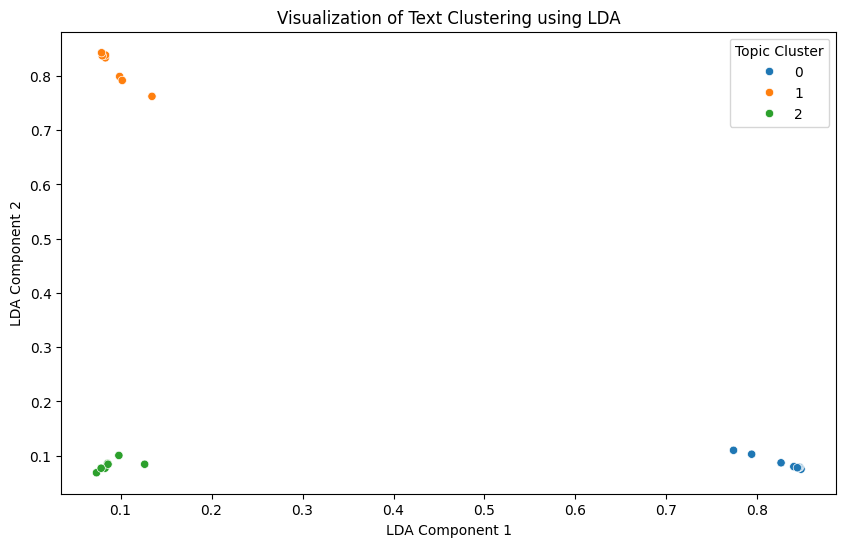

In [4]:
from sklearn.cluster import KMeans

def optimal_k(tfidf_matrix, max_k=10):
    from sklearn.metrics import silhouette_score
    best_k = 2 ## ini adalah nilai default, nanti akan diupdate dengan nilai k terbaik
    best_score = -1
    for k in range(2, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(tfidf_matrix)
        score = silhouette_score(tfidf_matrix, labels)
        if score > best_score:
            best_k = k
            best_score = score
    return best_k

## TODO: Bagaimana cara mendapatkan jumlah cluster yang optimal menggunakan metode silhouette score? ##
num_clusters = optimal_k(tfidf_matrix, max_k=min(10, tfidf_matrix.shape[0] - 1))

# Apply KMeans clustering
## TODO: inisialisasi KMeans dengan jumlah cluster optimal yang sudah didapatkan ##
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
negative_fuel_df['cluster'] = kmeans.fit_predict(tfidf_matrix)

# Display clustered sentences
print(negative_fuel_df[['sentence', 'cluster']].sort_values(by='cluster'))


import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.decomposition import LatentDirichletAllocation

# Perform LDA for topic modeling
num_topics = 3  # Adjust the number of topics as needed
lda = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda_matrix = lda.fit_transform(tfidf_matrix)

# Assign the most probable topic to each sentence
negative_fuel_df['LDA_Topic'] = np.argmax(lda_matrix, axis=1)

# Visualize the clustering
plt.figure(figsize=(10, 6))
sns.scatterplot(x=lda_matrix[:, 0], y=lda_matrix[:, 1], hue=negative_fuel_df['LDA_Topic'], palette="tab10")
plt.xlabel("LDA Component 1")
plt.ylabel("LDA Component 2")
plt.title("Visualization of Text Clustering using LDA")
plt.legend(title="Topic Cluster")
plt.show()


In [5]:
# Function to display the top words for each topic
def display_topics(model, feature_names, num_words=10):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        topics[f"Topic {topic_idx}"] = [feature_names[i] for i in topic.argsort()[:-num_words - 1:-1]]
    
    topics_df = pd.DataFrame(topics)
    
    return topics_df

# Get feature names from the TF-IDF vectorizer
## TODO: Bagaimana cara mendapatkan feature names dari vectorizer? ##
feature_names = vectorizer.get_feature_names_out()

# Display the top words in each topic
topics = display_topics(lda, feature_names)
topics.head()

,Topic 0,Topic 1,Topic 2
0,nya,boros,punya
1,avanza,juga,memang
2,boros,nya,xenia
3,bakar,ya,yang
4,bahan,oke,saya


In [6]:
# Function to display the top words for each topic per cluster
def display_cluster_topics(model, feature_names, num_words=10):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        topics[f"Topic {topic_idx}"] = [feature_names[i] for i in topic.argsort()[:-num_words - 1:-1]]
    
    # Convert topics to a DataFrame for display
    topics_df = pd.DataFrame(topics)

    # Associate topics with clusters
    cluster_topics = negative_fuel_df[['sentence', 'LDA_Topic']].copy()
    cluster_topics['Topic Words'] = cluster_topics['LDA_Topic'].apply(lambda x: ", ".join(topics_df[f"Topic {x}"]))
    
    return cluster_topics

# Get feature names from the TF-IDF vectorizer
feature_names = vectorizer.get_feature_names_out()

# Display the top words in each topic per cluster
topic_cluster = display_cluster_topics(lda, feature_names)
topic_cluster.head()        

,sentence,LDA_Topic,Topic Words
1,Avanza kenapa jadi boros bensin begini dah ah....,0,"nya, avanza, boros, bakar, bahan, banget, akhi..."
38,"dari segi kenyamanan cortez oke lah, tapi baha...",0,"nya, avanza, boros, bakar, bahan, banget, akhi..."
113,kalau sudah di atas 120 km / jam boros banget ...,2,"punya, memang, xenia, yang, saya, iya, gue, be..."
116,Rush konde konsumsi BBM yang tetap irit .,1,"boros, juga, nya, ya, oke, tapi, dan, jauh, va..."
124,pengalaman saya punya avanza bahan bakar nya l...,2,"punya, memang, xenia, yang, saya, iya, gue, be..."


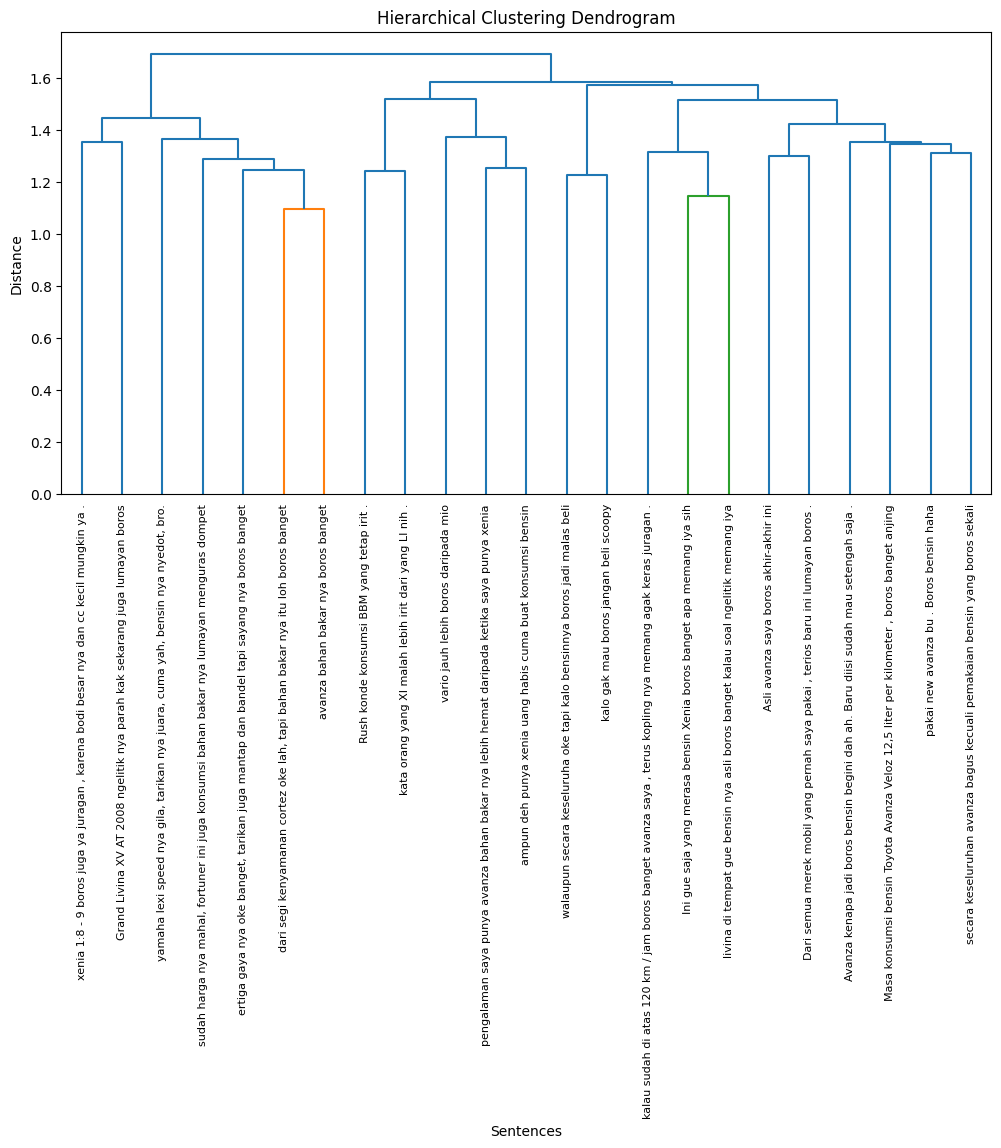

In [7]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

# Perform hierarchical clustering
linkage_matrix = sch.linkage(tfidf_matrix.toarray(), method='ward')

# Plot the dendrogram
plt.figure(figsize=(12, 6))
sch.dendrogram(linkage_matrix, labels=negative_fuel_df['sentence'].values, leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sentences")
plt.ylabel("Distance")
plt.show()
        

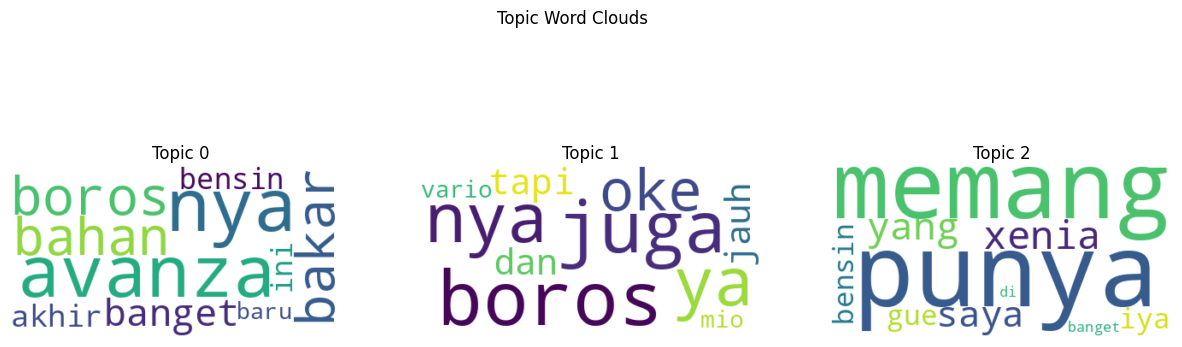

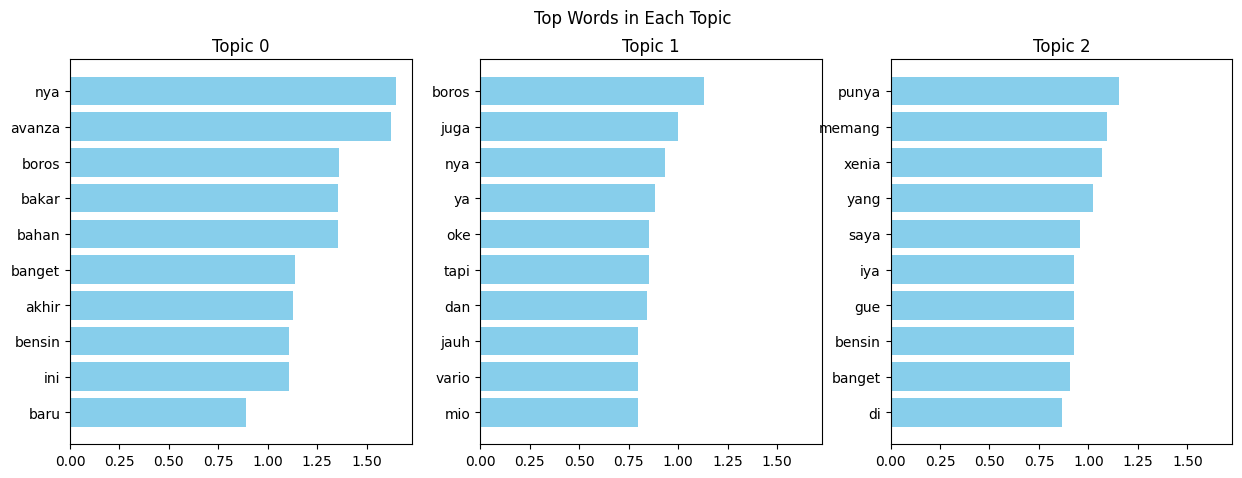

In [8]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np

# Function to plot word clouds for topics
def plot_word_clouds(model, feature_names, num_words=10):
    fig, axes = plt.subplots(1, model.n_components, figsize=(15, 5))
    for topic_idx, topic in enumerate(model.components_):
        word_freqs = {feature_names[i]: topic[i] for i in topic.argsort()[:-num_words - 1:-1]}
        wordcloud = WordCloud(background_color="white").generate_from_frequencies(word_freqs)
        axes[topic_idx].imshow(wordcloud, interpolation='bilinear')
        axes[topic_idx].axis("off")
        axes[topic_idx].set_title(f"Topic {topic_idx}")
    plt.suptitle("Topic Word Clouds")
    plt.show()

# Function to plot bar charts of top words per topic
def plot_top_words(model, feature_names, num_words=10):
    fig, axes = plt.subplots(1, model.n_components, figsize=(15, 5), sharex=True)
    for topic_idx, topic in enumerate(model.components_):
        top_features_indices = topic.argsort()[:-num_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_indices]
        top_weights = topic[top_features_indices]

        axes[topic_idx].barh(top_features, top_weights, color='skyblue')
        axes[topic_idx].invert_yaxis()
        axes[topic_idx].set_title(f"Topic {topic_idx}")

    plt.suptitle("Top Words in Each Topic")
    plt.show()

# Get feature names from the TF-IDF vectorizer
feature_names = vectorizer.get_feature_names_out()

# Plot word clouds and top words for topics
plot_word_clouds(lda, feature_names)
plot_top_words(lda, feature_names)

## 5. Clustering using word2vec

In [9]:
def average_word_vectors(words, model, vocabulary, num_features):
    feature_vector = np.zeros((num_features,), dtype="float64")
    nwords = 0.0

    for word in words:
        if word in vocabulary:
            nwords += 1.0
            feature_vector = np.add(feature_vector, model.wv[word])

    if nwords:
        feature_vector = np.divide(feature_vector, nwords)

    return feature_vector


# Function to vectorize sentences using the Word2Vec model
def averaged_word_vectorizer(corpus, model, num_features):
    vocabulary = set(model.wv.index_to_key)  # Get vocabulary words
    features = [
        average_word_vectors(tokenized_sentence, model,
                             vocabulary, num_features)
        for tokenized_sentence in corpus
    ]
    return np.array(features)

Epoch: 1, Loss: 98768.6562
Epoch: 2, Loss: 98884.0312
Epoch: 3, Loss: 96630.2812
Epoch: 4, Loss: 92204.7188
Epoch: 5, Loss: 81468.0312
Epoch: 6, Loss: 75739.3438
Epoch: 7, Loss: 73220.8125
Epoch: 8, Loss: 70715.5000
Epoch: 9, Loss: 68455.9375
Epoch: 10, Loss: 66283.3750
Epoch: 11, Loss: 66984.3125
Epoch: 12, Loss: 65663.9375
Epoch: 13, Loss: 65678.5625
Epoch: 14, Loss: 63928.2500
Epoch: 15, Loss: 65346.1250
Epoch: 16, Loss: 63948.1250
Epoch: 17, Loss: 63655.8750
Epoch: 18, Loss: 63541.5000
Epoch: 19, Loss: 62686.2500
Epoch: 20, Loss: 62421.7500
Epoch: 21, Loss: 62553.3750
Epoch: 22, Loss: 63213.8750
Epoch: 23, Loss: 62073.1250
Epoch: 24, Loss: 62730.1250
Epoch: 25, Loss: 61731.6250
Epoch: 26, Loss: 61640.6250
Epoch: 27, Loss: 62098.7500
Epoch: 28, Loss: 61195.0000
Epoch: 29, Loss: 62492.6250
Epoch: 30, Loss: 62312.0000


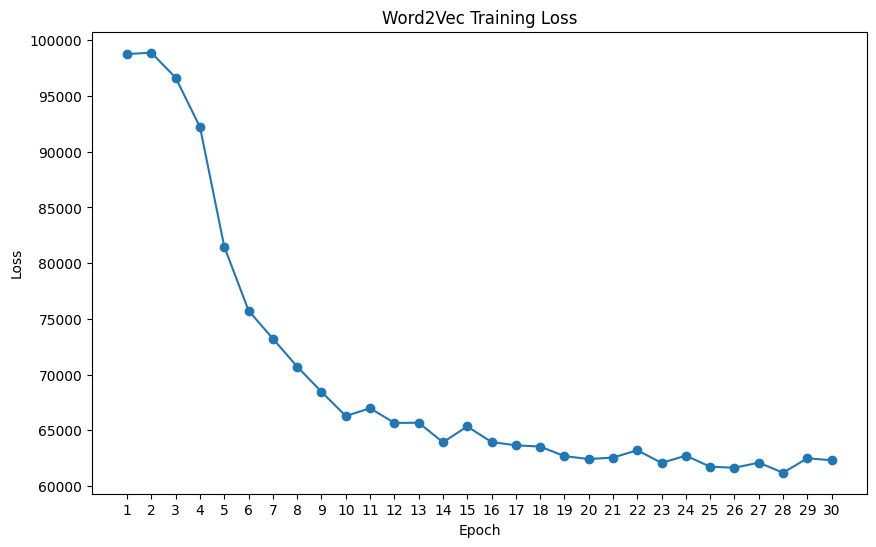


Words similar to 'mobil':
  innova: 0.9518
  Harga: 0.9513
  menengah: 0.9509
  stabil: 0.9508
  lcgc: 0.9481
  indonesia: 0.9477
  spesifikasi: 0.9460
  pemakaian: 0.9460
  Confero: 0.9455
  Dan: 0.9442

Words similar to 'bensin':
  avanza: 0.9388
  boros: 0.9388
  lumayan: 0.9260
  xenia: 0.9170
  BBM: 0.9139
  isi: 0.9078
  kabin: 0.9065
  bandel: 0.9043
  juara: 0.9037
  konsumsi: 0.9019

Words similar to 'boros':
  avanza: 0.9679
  bensin: 0.9388
  xenia: 0.9216
  juara: 0.8968
  lumayan: 0.8890
  penuh: 0.8885
  bandel: 0.8837
  banget: 0.8821
  kak: 0.8768
  luas: 0.8624

Words similar to 'avanza':
  boros: 0.9679
  xenia: 0.9443
  bensin: 0.9388
  penuh: 0.9241
  juara: 0.9170
  bandel: 0.9084
  lumayan: 0.9040
  kak: 0.9008
  luas: 0.8936
  mantap: 0.8908

Words similar to 'bbm':
  kota: 0.9663
  irit: 0.9493
  konsumsi: 0.9164
  Rush: 0.9085
  lumayan: 0.9069
  dikendarai: 0.9063
  BBM: 0.9058
  kabin: 0.9056
  hemat: 0.8952
  dipakai: 0.8914

Words similar to 'konsumsi':
  

In [24]:
import gensim
from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec
import numpy as np
import matplotlib.pyplot as plt

# Loss tracking callback
class EpochLogger(CallbackAny2Vec):
    def __init__(self):
        self.epoch = 0
        self.losses = []
        self.previous_loss = 0.0
        
    def on_epoch_end(self, model):
        cumulative_loss = model.get_latest_training_loss()
        current_loss = cumulative_loss - self.previous_loss
        self.losses.append(current_loss)
        self.previous_loss = cumulative_loss
        self.epoch += 1
        print(f'Epoch: {self.epoch}, Loss: {current_loss:.4f}')


# Use each sentence once so the training corpus is not biased by duplicate subsets
all_sentences = [
    enhanced_tokenizer(sent)
    for sent in df['sentence'].dropna().drop_duplicates()
]
all_sentences = [tokens for tokens in all_sentences if tokens]

# Initialize callback
epoch_logger = EpochLogger()

# Train an enhanced Word2Vec model
## TODO: Bagaimana cara melatih model Word2Vec dengan callback epoch_logger? ##
w2v_model = Word2Vec(
    vector_size=100,
    window=5,
    min_count=1,
    workers=1,
    sg=1,
    seed=42,
    compute_loss=True
)
w2v_model.build_vocab(all_sentences)
w2v_model.train(
    all_sentences,
    total_examples=w2v_model.corpus_count,
    epochs=30,
    compute_loss=True,
    callbacks=[epoch_logger]
)

# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(epoch_logger.losses) + 1), epoch_logger.losses, marker='o')
plt.title('Word2Vec Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(1, len(epoch_logger.losses) + 1))
plt.show()



# Evaluate similarity for key terms
test_words = ["mobil", "bensin", "boros", "avanza", "bbm", "konsumsi"]
for word in test_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=10)
        print(f"\nWords similar to '{word}':")
        for term, score in similar:
            print(f"  {term}: {score:.4f}")



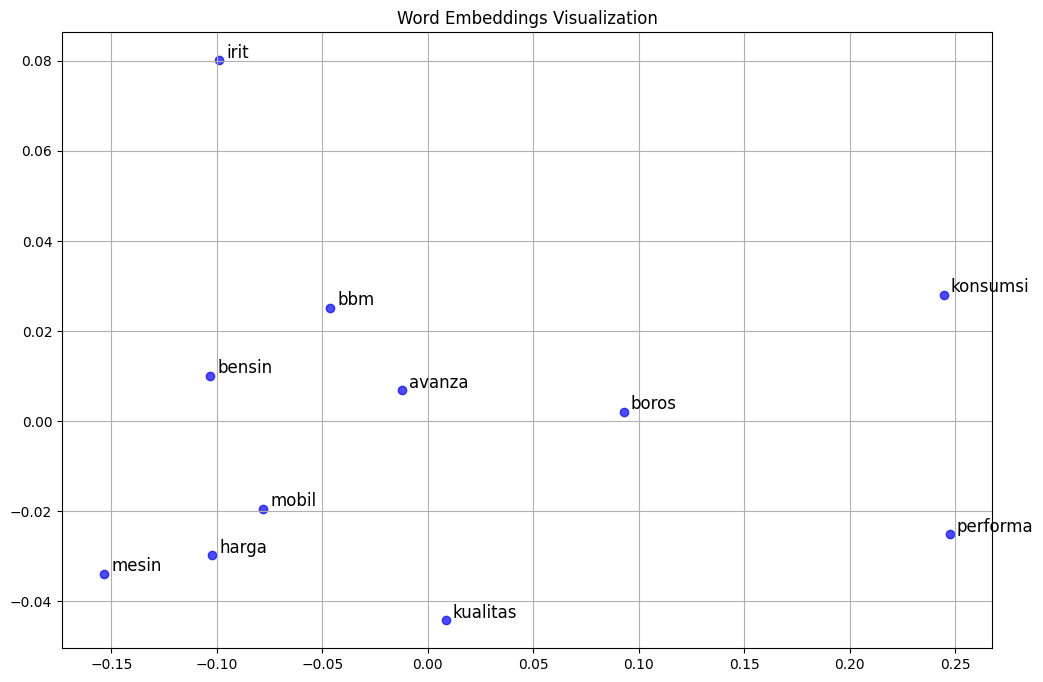

In [11]:
from sklearn.decomposition import PCA


def plot_word_vectors(model, words):
# Extract vectors for the words
    word_vectors = [model.wv[word] for word in words if word in
    model.wv]
    words_found = [word for word in words if word in model.wv]
    # Apply PCA to reduce to 2 dimensions
    pca = PCA(n_components=2)
    reduced_vectors = pca.fit_transform(word_vectors)
    # Plot
    plt.figure(figsize=(12, 8))
    plt.scatter(reduced_vectors[:, 0],
    reduced_vectors[:, 1], c='blue', alpha=0.7)
    # Add labels for each point
    for i, word in enumerate(words_found):
        plt.annotate(word, xy=(reduced_vectors[i, 0],
        reduced_vectors[i, 1]),
        xytext=(5, 2), textcoords='offset points',
        fontsize=12, color='black')
    plt.title('Word Embeddings Visualization')
    plt.grid(True)
    plt.show()


# Visualize vectors for automotive terms
automotive_terms = ["mobil", "bensin", "bahan_bakar", "avanza", "bbm", "konsumsi",
                    "boros", "irit", "mesin", "performa", "harga", "kualitas"]
plot_word_vectors(w2v_model, automotive_terms)

In [12]:
from sklearn.cluster import AffinityPropagation
from sklearn.decomposition import PCA
# Tokenize the sentences for word2vec vectorization
tokenized_sentences = [enhanced_tokenizer(sent) for sent in
                       negative_fuel_df['sentence']]
# Generate feature vectors using Word2Vec model
w2v_feature_array = averaged_word_vectorizer(
    corpus=tokenized_sentences, model=w2v_model,
    num_features=w2v_model.vector_size
)

In [13]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


def apply_kmeans_clustering(feature_array, max_clusters=10):
    """
    Apply KMeans clustering with evaluation metrics to find optimal
    number of clusters
    """
    # Metrics for evaluation
    silhouette_scores = []
    inertias = []
    # Try different numbers of clusters
    for n_clusters in range(2, max_clusters + 1):
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(feature_array)
        # Calculate evaluation metrics (silhouette may fail for invalid cases)
        try:
            silhouette = silhouette_score(feature_array, cluster_labels)
        except Exception:
            silhouette = float('nan')
        inertia = kmeans.inertia_
        silhouette_scores.append(silhouette)
        inertias.append(inertia)
        print(
            f"KMeans with {n_clusters} clusters - Silhouette: {silhouette:.4f}, Inertia: {inertia:.4f}")
    # Plot silhouette scores and inertia (elbow method)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(range(2, max_clusters + 1), silhouette_scores, 'o-')
    ax1.set_xlabel('Number of clusters')
    ax1.set_ylabel('Silhouette Score')
    ax1.set_title('Silhouette Score vs. Number of Clusters')
    ax1.grid(True)
    ax2.plot(range(2, max_clusters + 1), inertias, 'o-')
    ax2.set_xlabel('Number of clusters')
    ax2.set_ylabel('Inertia')
    ax2.set_title('Elbow Method for Optimal k')
    ax2.grid(True)
    plt.tight_layout()
    plt.show()
    # Determine optimal number of clusters based on silhouette score
    if all(np.isnan(silhouette_scores)):
        optimal_clusters = None
        print("Could not compute silhouette scores for any k; optimal_clusters set to None")
    else:
        optimal_clusters = int(np.nanargmax(silhouette_scores)) + 2
        print(
            f"Optimal number of clusters based on silhouette score: {optimal_clusters}")
    return optimal_clusters



KMeans with 2 clusters - Silhouette: 0.6110, Inertia: 0.1714
KMeans with 3 clusters - Silhouette: 0.4844, Inertia: 0.0971
KMeans with 4 clusters - Silhouette: 0.4321, Inertia: 0.0648
KMeans with 5 clusters - Silhouette: 0.4488, Inertia: 0.0388
KMeans with 6 clusters - Silhouette: 0.3883, Inertia: 0.0305
KMeans with 7 clusters - Silhouette: 0.3594, Inertia: 0.0246
KMeans with 8 clusters - Silhouette: 0.3354, Inertia: 0.0194


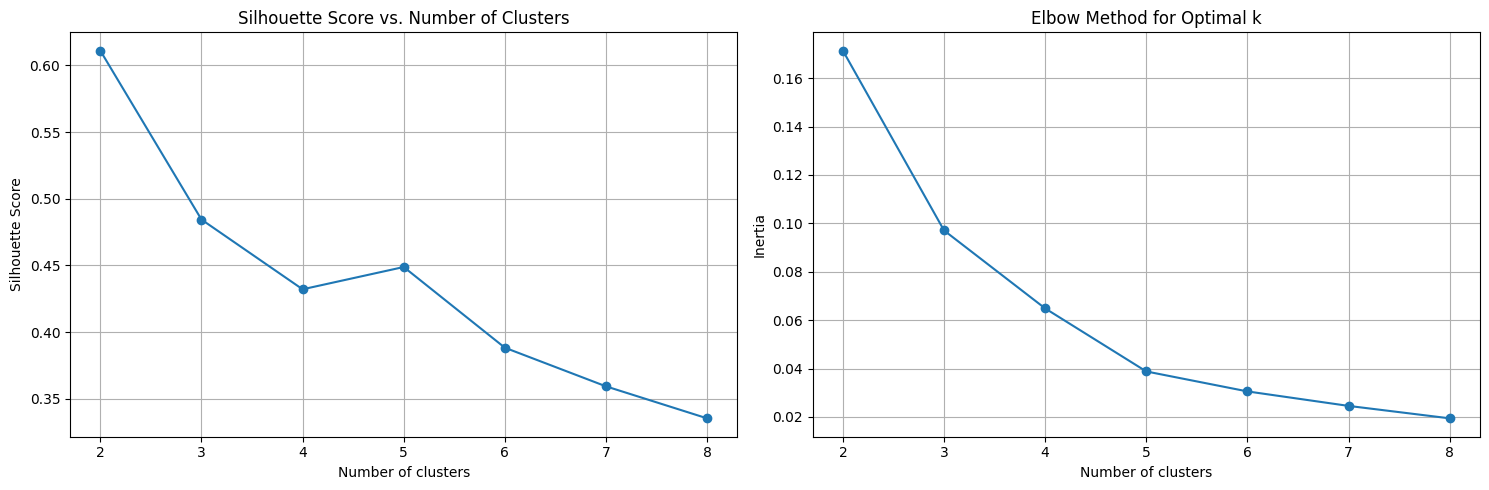

Optimal number of clusters based on silhouette score: 2

KMeans Clustering Results:

Cluster 0:
- dari segi kenyamanan cortez oke lah, tapi bahan bakar nya itu loh boros banget
 ... and 11 more sentences
- kalau sudah di atas 120 km / jam boros banget avanza saya , terus kopling nya memang agak keras juragan .
 ... and 11 more sentences
- pengalaman saya punya avanza bahan bakar nya lebih hemat daripada ketika saya punya xenia
 ... and 11 more sentences

Cluster 1:
- Avanza kenapa jadi boros bensin begini dah ah. Baru diisi sudah mau setengah saja .
 ... and 6 more sentences
- Rush konde konsumsi BBM yang tetap irit .
 ... and 6 more sentences
- Asli avanza saya boros akhir-akhir ini
 ... and 6 more sentences


In [14]:
# Find optimal number of clusters for KMeans
optimal_k = apply_kmeans_clustering(w2v_feature_array, max_clusters=8)
# Apply KMeans with optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(w2v_feature_array)
# Add KMeans labels to the dataframe
negative_fuel_df['W2V_KMeans_Cluster'] = kmeans_labels
# Display KMeans clustering results
print("\nKMeans Clustering Results:")
for cluster in range(optimal_k):
    print(f"\nCluster {cluster}:")
    cluster_sentences = negative_fuel_df[negative_fuel_df['W2V_KMeans_Cluster'] == cluster]
    sentences = cluster_sentences['sentence'].values
    for sentence in sentences[:3]: # Show first 3 sentences in each cluster
        print(f"- {sentence}")
        if len(sentences) > 3:
            print(f" ... and {len(sentences) - 3} more sentences")

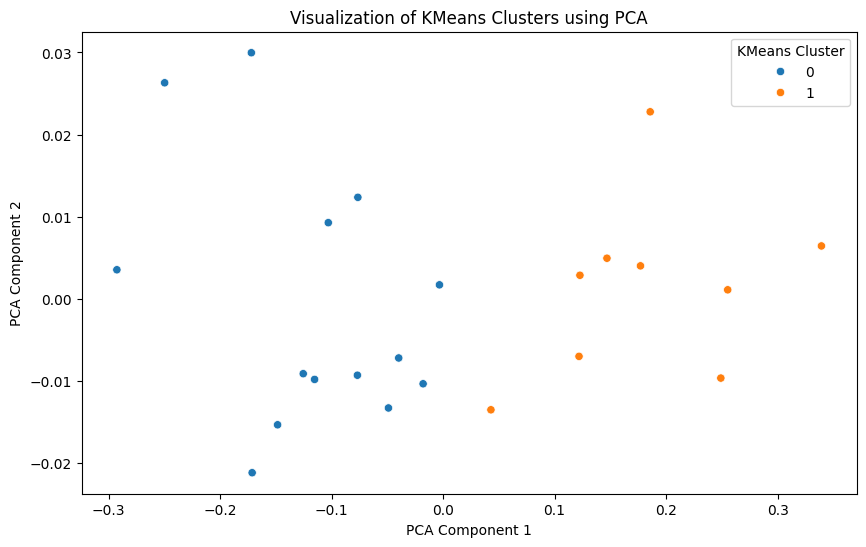

In [15]:
## plot Kmeans clusters using PCA

pca = PCA(n_components=optimal_k)
reduced_features = pca.fit_transform(w2v_feature_array)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=reduced_features[:, 0], y=reduced_features[:, 1],
                hue=negative_fuel_df['W2V_KMeans_Cluster'], palette="tab10")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Visualization of KMeans Clusters using PCA")
plt.legend(title="KMeans Cluster")
plt.show()



## 6. Hamming distance similarity

In [16]:
from scipy.spatial.distance import hamming
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Convert each sentence into a binary vector showing presence/absence of words
all_words = set()
for sent in negative_fuel_df['sentence']:
    tokens = enhanced_tokenizer(sent)
    all_words.update(tokens)
# Create binary vectors for each sentence
binary_vectors = []
sentences = negative_fuel_df['sentence'].values
for sent in sentences:
    tokens = set(enhanced_tokenizer(sent))
    vector = [1 if word in tokens else 0 for word in all_words]
    binary_vectors.append(vector)
# Calculate Hamming distances between all pairs
n_sentences = len(sentences)
hamming_matrix = np.zeros((n_sentences, n_sentences))
for i in range(n_sentences):
    for j in range(n_sentences):
        hamming_matrix[i, j] = hamming(binary_vectors[i], binary_vectors[j])

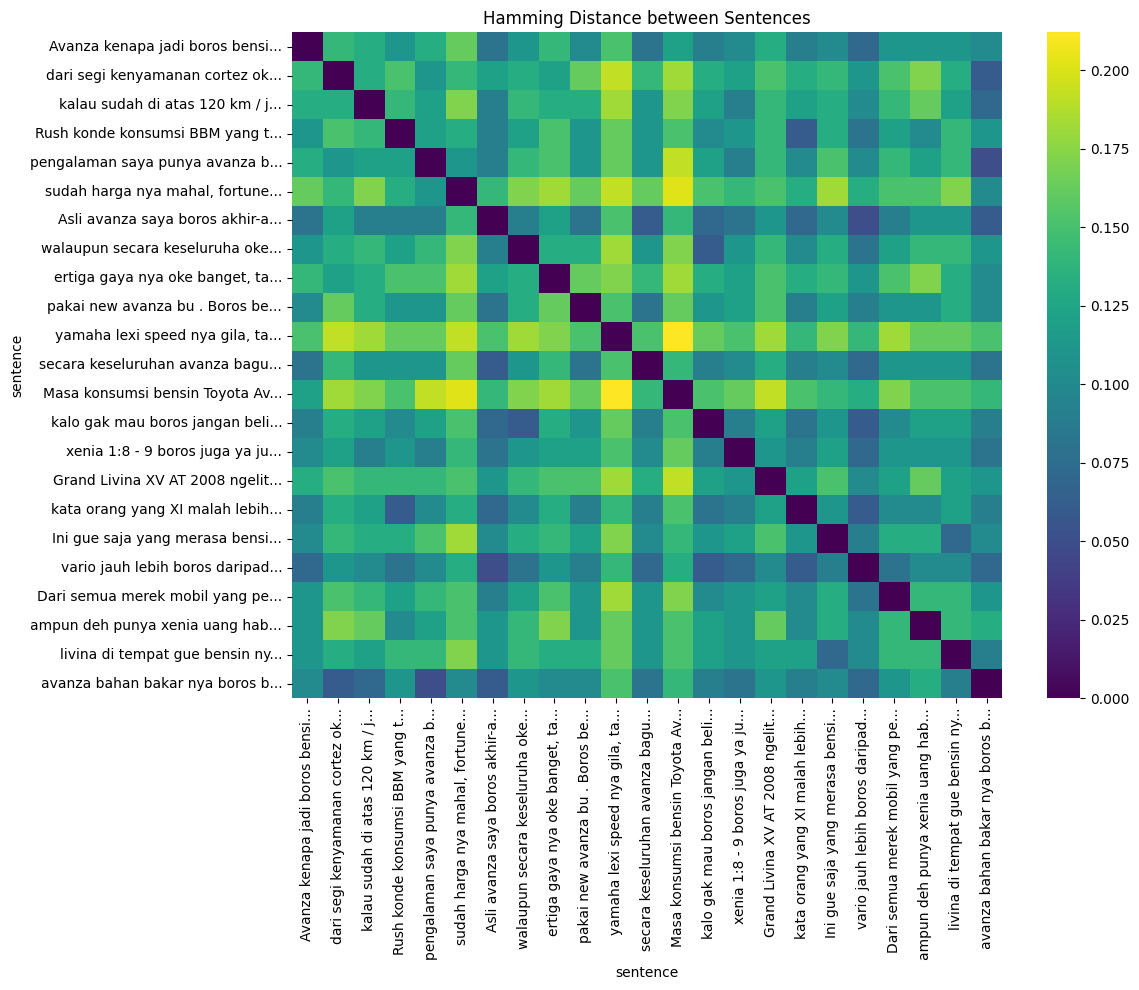


Most similar sentences based on Hamming distance:

Sentence: Avanza kenapa jadi boros bensin begini dah ah. Bar...
  Similar: vario jauh lebih boros daripada mio... (Hamming Distance: 0.0707)
  Similar: secara keseluruhan avanza bagus kecuali pemakaian ... (Hamming Distance: 0.0808)
  Similar: Asli avanza saya boros akhir-akhir ini... (Hamming Distance: 0.0808)
  Similar: kata orang yang XI malah lebih irit dari yang LI n... (Hamming Distance: 0.0909)
  Similar: kalo gak mau boros jangan beli scoopy... (Hamming Distance: 0.0909)

Sentence: dari segi kenyamanan cortez oke lah, tapi bahan ba...
  Similar: avanza bahan bakar nya boros banget... (Hamming Distance: 0.0606)
  Similar: vario jauh lebih boros daripada mio... (Hamming Distance: 0.1111)
  Similar: pengalaman saya punya avanza bahan bakar nya lebih... (Hamming Distance: 0.1111)
  Similar: xenia 1:8 - 9 boros juga ya juragan , karena bodi ... (Hamming Distance: 0.1212)
  Similar: ertiga gaya nya oke banget, tarikan juga mantap da

In [17]:
hamming_df = pd.DataFrame(
    hamming_matrix,
    index=negative_fuel_df['sentence'].str[:30] + '...',
    columns=negative_fuel_df['sentence'].str[:30] + '...'
)
# Plot the Hamming distance matrix
plt.figure(figsize=(12, 10))
sns.heatmap(hamming_df, cmap='viridis')
plt.title('Hamming Distance between Sentences')
plt.tight_layout()
plt.show()

def most_similar_sentences(hamming_matrix, sentences, top_n=5):
    n = len(sentences)
    similar_sentences = {}
    for i in range(n):
        distances = hamming_matrix[i]
        sorted_indices = np.argsort(distances)
        similar_sentences[sentences[i]] = [(sentences[idx], distances[idx]) for idx in sorted_indices[1:top_n+1]]
    return similar_sentences

## TODO: Bagaimana cara mendapatkan kalimat-kalimat yang paling mirip berdasarkan matriks Hamming? ##
similar_sentences = most_similar_sentences(hamming_matrix, sentences)

print("\nMost similar sentences based on Hamming distance:")
for sentence, similars in similar_sentences.items():
    print(f"\nSentence: {sentence[:50]}...")
    for similar_sentence, distance in similars:
        print(f"  Similar: {similar_sentence[:50]}... (Hamming Distance: {distance:.4f})")

## 7. Manhattan Distance similarity

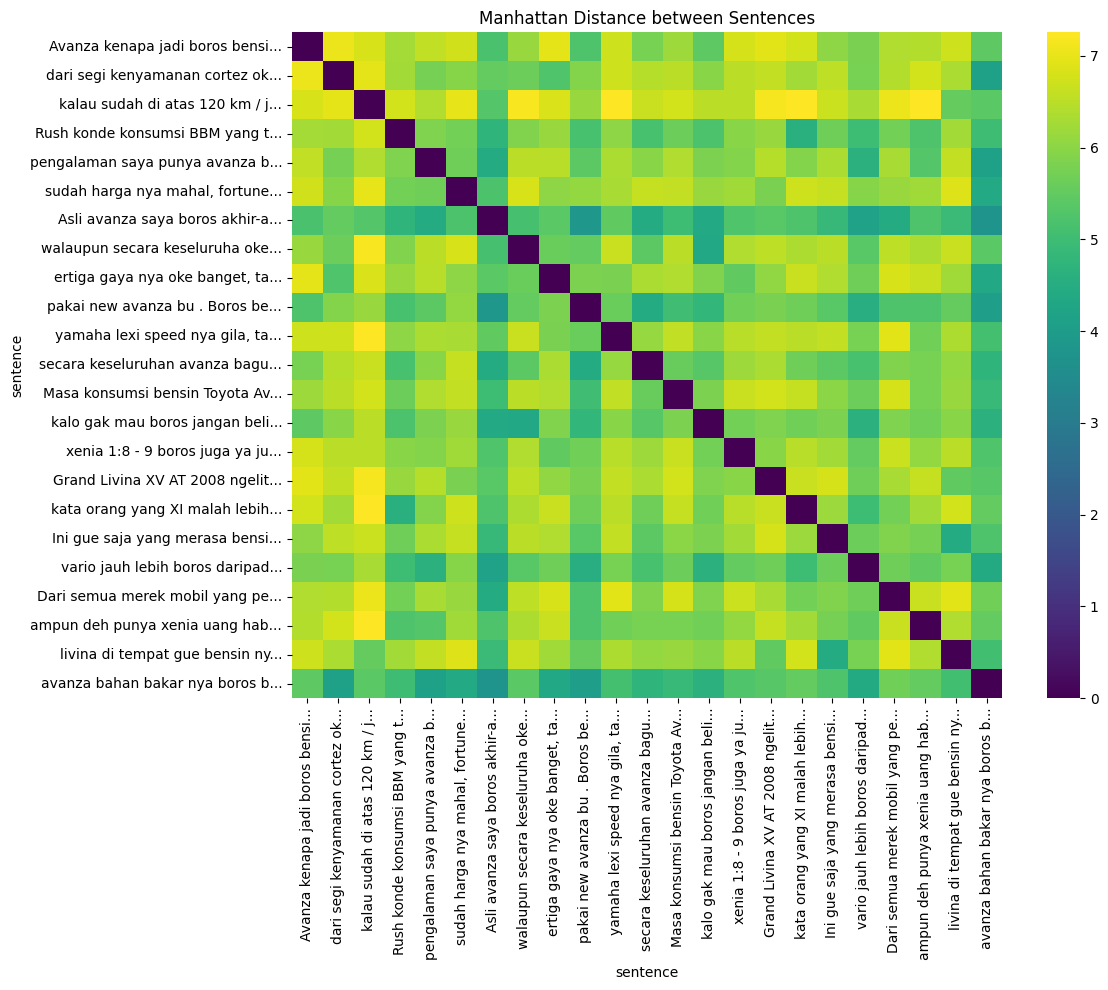


Most similar sentences based on Manhattan distance:

Sentence: Avanza kenapa jadi boros bensin begini dah ah. Bar...
  Similar: Asli avanza saya boros akhir-akhir ini... (Manhattan Distance: 5.1740)
  Similar: pakai new avanza bu . Boros bensin haha... (Manhattan Distance: 5.2417)
  Similar: kalo gak mau boros jangan beli scoopy... (Manhattan Distance: 5.4466)
  Similar: avanza bahan bakar nya boros banget... (Manhattan Distance: 5.4618)
  Similar: secara keseluruhan avanza bagus kecuali pemakaian ... (Manhattan Distance: 5.7635)

Sentence: dari segi kenyamanan cortez oke lah, tapi bahan ba...
  Similar: avanza bahan bakar nya boros banget... (Manhattan Distance: 4.1355)
  Similar: ertiga gaya nya oke banget, tarikan juga mantap da... (Manhattan Distance: 5.2592)
  Similar: Asli avanza saya boros akhir-akhir ini... (Manhattan Distance: 5.5030)
  Similar: walaupun secara keseluruha oke tapi kalo bensinnya... (Manhattan Distance: 5.6249)
  Similar: pengalaman saya punya avanza bahan bak

In [18]:
from scipy.spatial.distance import cityblock
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate Manhattan distances between all pairs of sentences
n_sentences = len(negative_fuel_df)
## bagaimana cara inisialisasi matriks untuk menyimpan hasil perhitungan jarak Manhattan? ##
manhattan_matrix = np.zeros((n_sentences, n_sentences))
# Convert sparse matrix to dense for calculations
tfidf_dense = tfidf_matrix.toarray()

for i in range(n_sentences):
    for j in range(n_sentences):
    # Calculate using cityblock distance (Manhattan)
        manhattan_matrix[i, j] = cityblock(tfidf_dense[i],
        tfidf_dense[j])

manhattan_df = pd.DataFrame(
    manhattan_matrix,
    index=negative_fuel_df['sentence'].str[:30] + '...',
    columns=negative_fuel_df['sentence'].str[:30] + '...'
)

plt.figure(figsize=(12, 10))
sns.heatmap(manhattan_df, cmap='viridis')
plt.title('Manhattan Distance between Sentences')
plt.tight_layout()
plt.show()


def most_similar_sentences_manhattan(manhattan_matrix, sentences, top_n=5):
    n = len(sentences)
    similar_sentences = {}
    for i in range(n):
        distances = manhattan_matrix[i]
        sorted_indices = np.argsort(distances)
        similar_sentences[sentences[i]] = [(sentences[idx], distances[idx]) for idx in sorted_indices[1:top_n+1]]
    return similar_sentences

similar_sentences_manhattan = most_similar_sentences_manhattan(manhattan_matrix, sentences)

print("\nMost similar sentences based on Manhattan distance:")
for sentence, similars in similar_sentences_manhattan.items():
    print(f"\nSentence: {sentence[:50]}...")
    for similar_sentence, distance in similars:
        print(f"  Similar: {similar_sentence[:50]}... (Manhattan Distance: {distance:.4f})")
        

## 8. Cosine Distance similarity

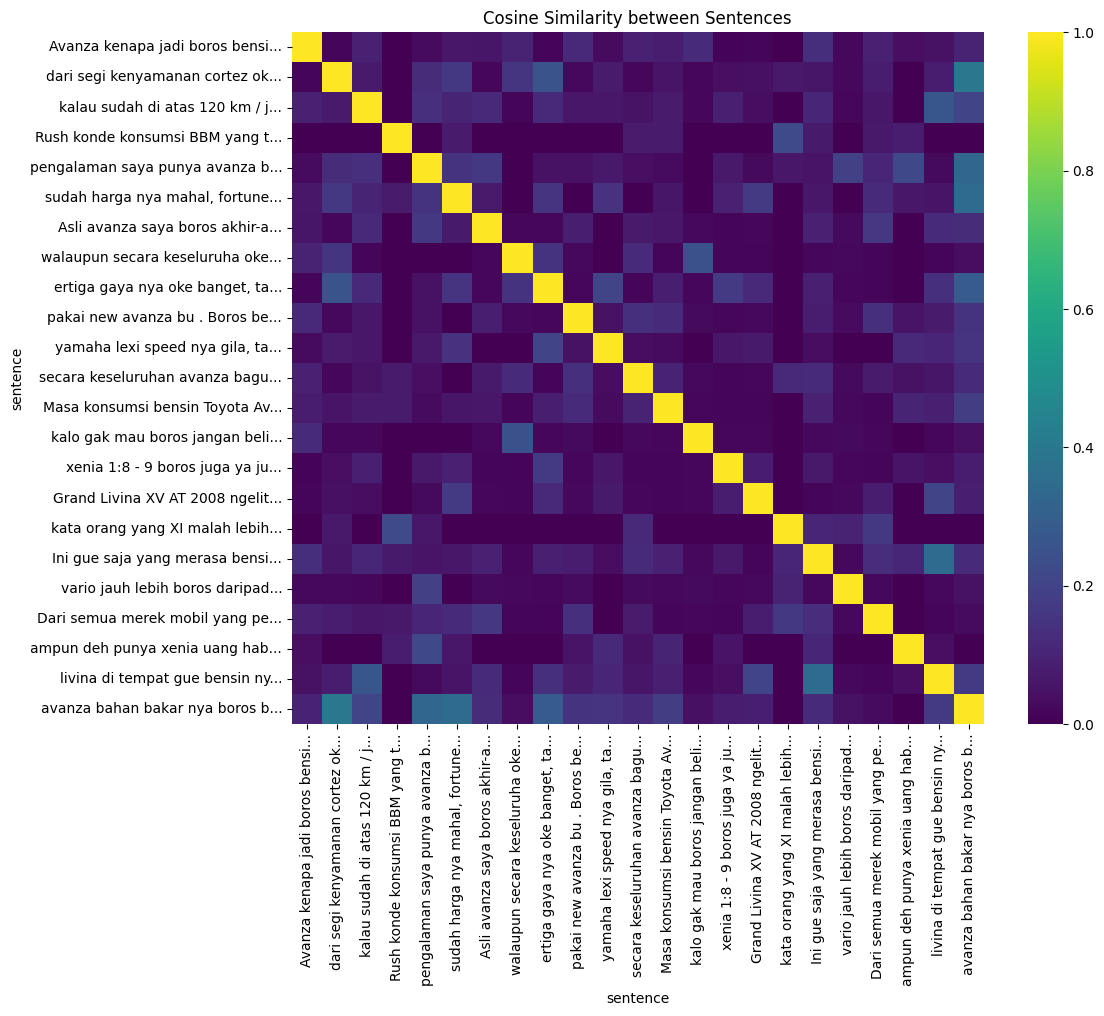


Most similar sentences based on Cosine Similarity:

Sentence: Avanza kenapa jadi boros bensin begini dah ah. Bar...
  Similar: Ini gue saja yang merasa bensin Xenia boros banget... (Cosine Similarity: 0.1321)
  Similar: kalo gak mau boros jangan beli scoopy... (Cosine Similarity: 0.1207)
  Similar: pakai new avanza bu . Boros bensin haha... (Cosine Similarity: 0.1128)
  Similar: walaupun secara keseluruha oke tapi kalo bensinnya... (Cosine Similarity: 0.0966)
  Similar: avanza bahan bakar nya boros banget... (Cosine Similarity: 0.0961)

Sentence: dari segi kenyamanan cortez oke lah, tapi bahan ba...
  Similar: avanza bahan bakar nya boros banget... (Cosine Similarity: 0.4010)
  Similar: ertiga gaya nya oke banget, tarikan juga mantap da... (Cosine Similarity: 0.2570)
  Similar: sudah harga nya mahal, fortuner ini juga konsumsi ... (Cosine Similarity: 0.1624)
  Similar: walaupun secara keseluruha oke tapi kalo bensinnya... (Cosine Similarity: 0.1554)
  Similar: pengalaman saya punya av

In [19]:
from sklearn.metrics.pairwise import cosine_similarity
# from scipy.spatial.distance import cosine 
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

# Calculate cosine similarity matrix using sklearn
## TODO: hitung cosine similarity antara kalimat menggunakan tfidf_matrix ##
cosine_similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Create a DataFrame for better visualization
cosine_df = pd.DataFrame(
    cosine_similarity_matrix,
    index=negative_fuel_df['sentence'].str[:30] + '...',
    columns=negative_fuel_df['sentence'].str[:30] + '...'
)

# Plot the cosine similarity matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cosine_df, cmap='viridis', annot=False, square=True)
plt.title('Cosine Similarity between Sentences')
plt.tight_layout()
plt.show()


def most_similar_sentences_cosine(similarity_matrix, sentences, top_n=5):
    """
    Find most similar sentences based on cosine similarity
    """
    n = len(sentences)
    similar_sentences = {}
    for i in range(n):
        similarities = similarity_matrix[i]
        # Get indices sorted by similarity (descending), excluding self-similarity
        sorted_indices = np.argsort(similarities)[::-1]
        # Get top N similar sentences (excluding the sentence itself at index 0)
        similar_sentences[sentences[i]] = [
            (sentences[idx], similarities[idx]) 
            for idx in sorted_indices[1:top_n+1]
        ]
    return similar_sentences

## TODO: Bagaimana cara mendapatkan kalimat-kalimat yang paling mirip berdasarkan matriks Cosine Similarity? ##
similar_sentences_cosine = most_similar_sentences_cosine(cosine_similarity_matrix, sentences)

print("\nMost similar sentences based on Cosine Similarity:")
for sentence, similars in similar_sentences_cosine.items():
    print(f"\nSentence: {sentence[:50]}...")
    for similar_sentence, similarity_score in similars:
        print(f"  Similar: {similar_sentence[:50]}... (Cosine Similarity: {similarity_score:.4f})")

## 9. Hellinger Distance similarity

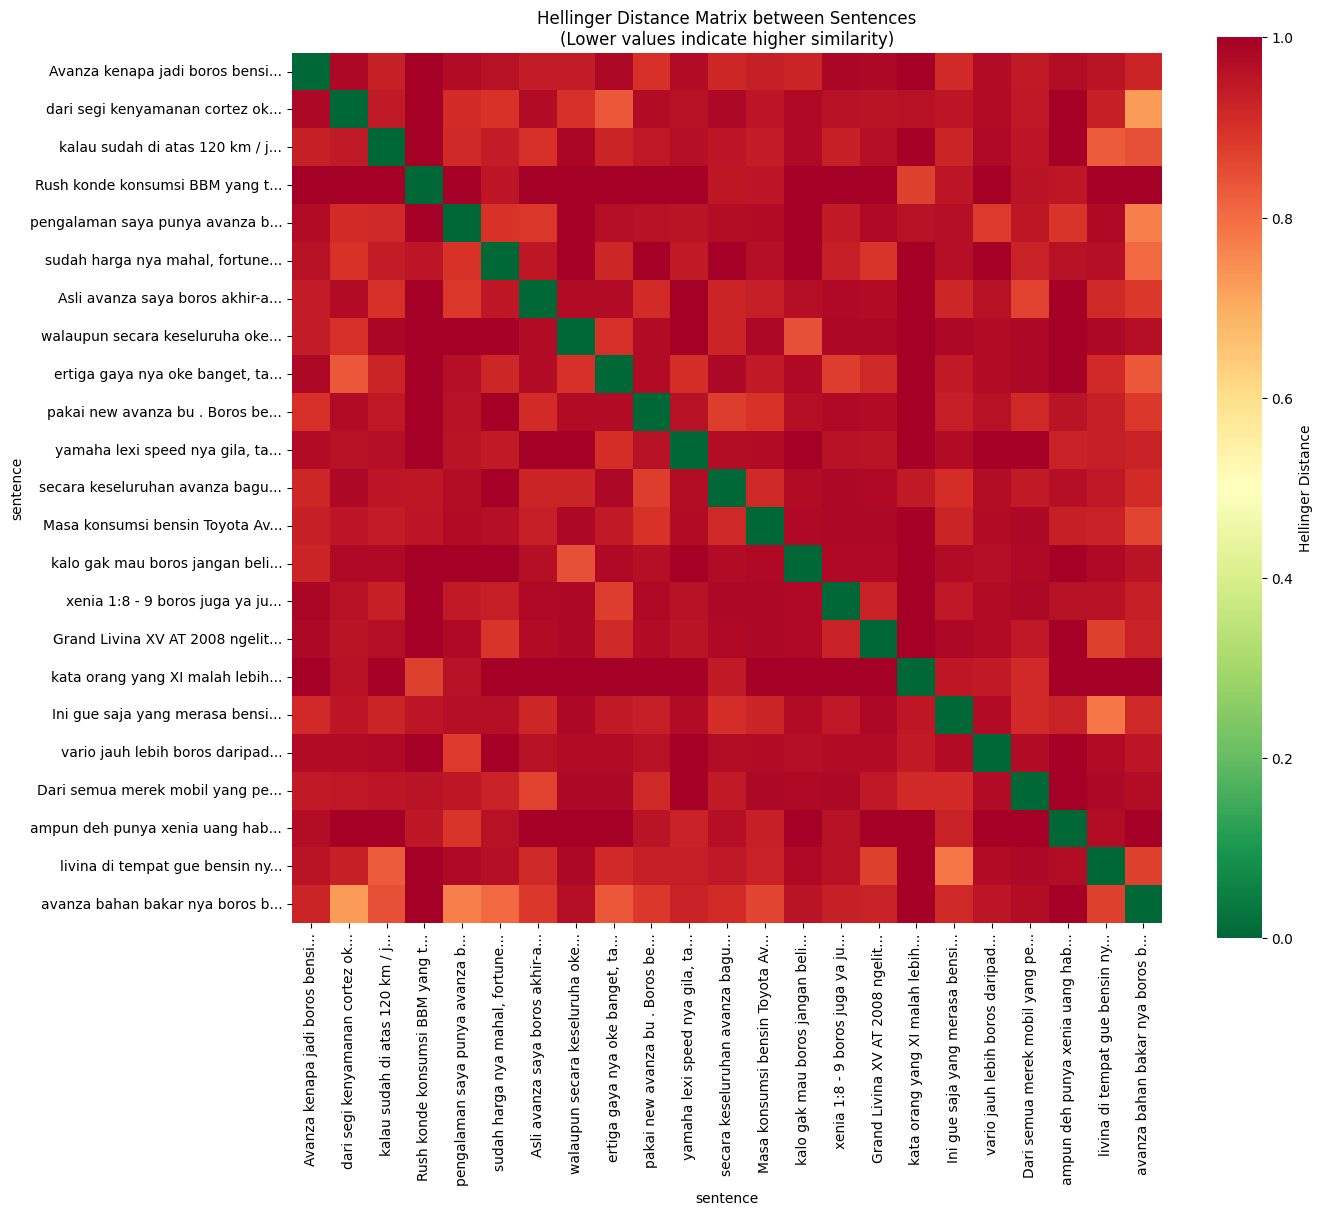


Most Similar Sentences Based on Hellinger Distance

Query Sentence: Avanza kenapa jadi boros bensin begini dah ah. Baru diisi su...
--------------------------------------------------------------------------------
  1. Similar: pakai new avanza bu . Boros bensin haha...
     Hellinger Distance: 0.900810
  2. Similar: Ini gue saja yang merasa bensin Xenia boros banget apa meman...
     Hellinger Distance: 0.913159
  3. Similar: secara keseluruhan avanza bagus kecuali pemakaian bensin yan...
     Hellinger Distance: 0.919760
  4. Similar: kalo gak mau boros jangan beli scoopy...
     Hellinger Distance: 0.922814
  5. Similar: avanza bahan bakar nya boros banget...
     Hellinger Distance: 0.924573

Query Sentence: dari segi kenyamanan cortez oke lah, tapi bahan bakar nya it...
--------------------------------------------------------------------------------
  1. Similar: avanza bahan bakar nya boros banget...
     Hellinger Distance: 0.729912
  2. Similar: ertiga gaya nya oke banget, tari

In [20]:
from scipy.stats import entropy
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

def hellinger(p, q):
    """
    Compute the Hellinger distance between two probability distributions.
    H(p, q) = sqrt(1 - BC(p, q))
    where BC is the Bhattacharyya coefficient: BC(p, q) = sum(sqrt(p_i * q_i))
    """
    # Ensure p and q are numpy arrays
    p = np.asarray(p, dtype=np.float64)
    q = np.asarray(q, dtype=np.float64)
    
    # Normalize to probability distributions
    p /= np.sum(p)
    q /= np.sum(q)
    
    # Compute Bhattacharyya coefficient
    bc = np.sum(np.sqrt(p * q))
    
    # Compute Hellinger distance
    return np.sqrt(1 - bc)


def normalize_to_probability(vector):
    """
    Normalize a vector to a probability distribution.
    Handles zero vectors and ensures numerical stability.
    Reference: Hellinger distance computation requires valid probability distributions
    """
    vector = np.asarray(vector, dtype=np.float64)
    vector = np.abs(vector)  # Ensure non-negative values
    total = np.sum(vector)
    
    if total == 0:
        # Handle zero vectors by using uniform distribution
        return np.ones(len(vector)) / len(vector)
    
    return vector / total

# Calculate Hellinger distances between all pairs of sentences using TF-IDF vectors
n_sentences = len(negative_fuel_df)
hellinger_matrix = np.zeros((n_sentences, n_sentences))

# Convert each TF-IDF vector to probability distribution and compute Hellinger distance
for i in range(n_sentences):
    for j in range(n_sentences):
        # Extract sparse vectors and convert to dense
        p = normalize_to_probability(tfidf_dense[i])
        q = normalize_to_probability(tfidf_dense[j])
        
        # Compute Hellinger distance: H(p,q) = sqrt(1 - BC(p,q))
        # where BC is Bhattacharyya coefficient
        hellinger_matrix[i, j] = hellinger(p, q)

# Create DataFrame for visualization
hellinger_df = pd.DataFrame(
    hellinger_matrix,
    index=negative_fuel_df['sentence'].str[:30] + '...',
    columns=negative_fuel_df['sentence'].str[:30] + '...'
)

# Plot the Hellinger distance matrix
plt.figure(figsize=(14, 12))
sns.heatmap(hellinger_df, cmap='RdYlGn_r', square=True, cbar_kws={'label': 'Hellinger Distance'})
plt.title('Hellinger Distance Matrix between Sentences\n(Lower values indicate higher similarity)')
plt.tight_layout()
plt.show()

def most_similar_sentences_hellinger(hellinger_matrix, sentences, top_n=5):
    """
    Find most similar sentences based on Hellinger distance.
    Lower distances indicate higher similarity.
    """
    n = len(sentences)
    similar_sentences = {}
    for i in range(n):
        distances = hellinger_matrix[i]
        # Get indices sorted by distance (ascending), excluding self-similarity
        sorted_indices = np.argsort(distances)
        # Get top N similar sentences (excluding the sentence itself at index 0)
        similar_sentences[sentences[i]] = [
            (sentences[idx], distances[idx]) 
            for idx in sorted_indices[1:top_n+1]
        ]
    return similar_sentences

## TODO: Bagaimana cara mendapatkan kalimat-kalimat yang paling mirip berdasarkan matriks Hellinger? ##
similar_sentences_hellinger = most_similar_sentences_hellinger(hellinger_matrix, sentences)

print("\n" + "="*80)
print("Most Similar Sentences Based on Hellinger Distance")
print("="*80)
for sentence, similars in similar_sentences_hellinger.items():
    print(f"\nQuery Sentence: {sentence[:60]}...")
    print("-" * 80)
    for i, (similar_sentence, distance) in enumerate(similars, 1):
        print(f"  {i}. Similar: {similar_sentence[:60]}...")
        print(f"     Hellinger Distance: {distance:.6f}")

## 10. Euclidean Distance similarity

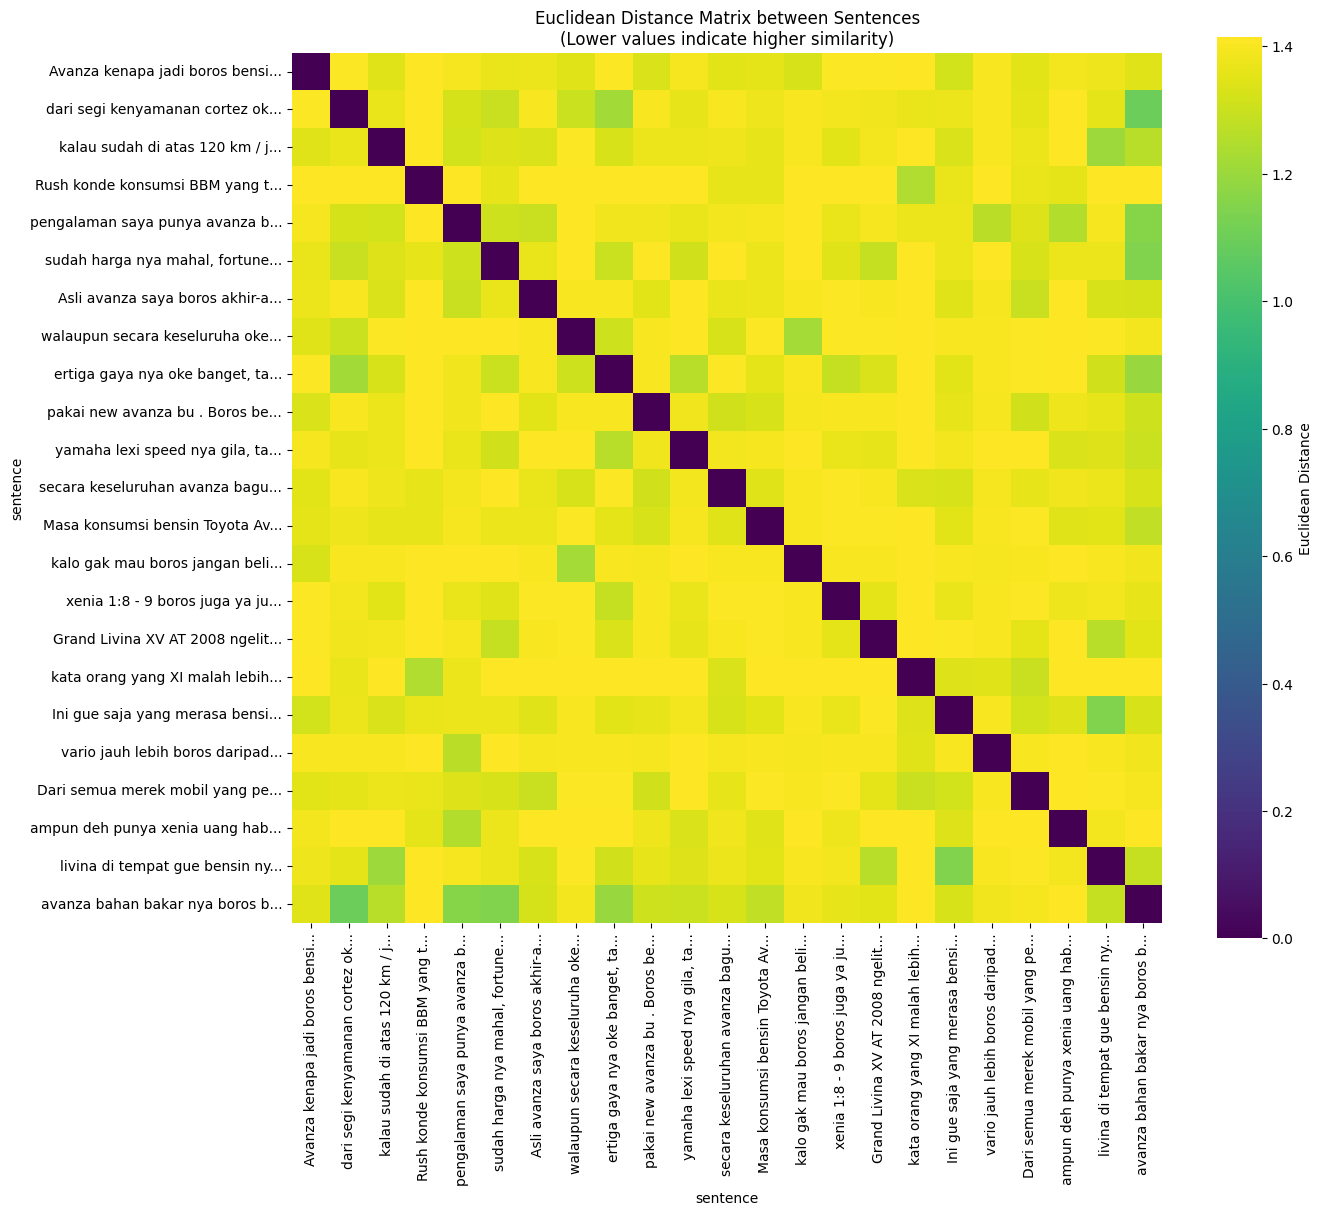


Most Similar Sentences Based on Euclidean Distance

Query Sentence: Avanza kenapa jadi boros bensin begini dah ah. Baru diisi su...
--------------------------------------------------------------------------------
  1. Similar: Ini gue saja yang merasa bensin Xenia boros banget apa meman...
     Euclidean Distance: 1.317511
  2. Similar: kalo gak mau boros jangan beli scoopy...
     Euclidean Distance: 1.326142
  3. Similar: pakai new avanza bu . Boros bensin haha...
     Euclidean Distance: 1.332056
  4. Similar: walaupun secara keseluruha oke tapi kalo bensinnya boros jad...
     Euclidean Distance: 1.344144
  5. Similar: avanza bahan bakar nya boros banget...
     Euclidean Distance: 1.344564

Query Sentence: dari segi kenyamanan cortez oke lah, tapi bahan bakar nya it...
--------------------------------------------------------------------------------
  1. Similar: avanza bahan bakar nya boros banget...
     Euclidean Distance: 1.094492
  2. Similar: ertiga gaya nya oke banget, tari

In [21]:
from scipy.spatial.distance import euclidean
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

# Calculate Euclidean distances between all pairs of sentences using TF-IDF vectors
n_sentences = len(negative_fuel_df)
euclidean_matrix = np.zeros((n_sentences, n_sentences))

# Convert sparse matrix to dense for calculations
for i in range(n_sentences):
    for j in range(n_sentences):
        euclidean_matrix[i, j] = euclidean(tfidf_dense[i], tfidf_dense[j])

# Create DataFrame for visualization
euclidean_df = pd.DataFrame(
    euclidean_matrix,
    index=negative_fuel_df['sentence'].str[:30] + '...',
    columns=negative_fuel_df['sentence'].str[:30] + '...'
)

# Plot the Euclidean distance matrix
plt.figure(figsize=(14, 12))
sns.heatmap(euclidean_df, cmap='viridis', square=True, cbar_kws={'label': 'Euclidean Distance'})
plt.title('Euclidean Distance Matrix between Sentences\n(Lower values indicate higher similarity)')
plt.tight_layout()
plt.show()

def most_similar_sentences_euclidean(euclidean_matrix, sentences, top_n=5):
    """
    Find most similar sentences based on Euclidean distance.
    Lower distances indicate higher similarity.
    """
    n = len(sentences)
    similar_sentences = {}
    for i in range(n):
        distances = euclidean_matrix[i]
        # Get indices sorted by distance (ascending), excluding self-similarity
        sorted_indices = np.argsort(distances)
        # Get top N similar sentences (excluding the sentence itself at index 0)
        similar_sentences[sentences[i]] = [
            (sentences[idx], distances[idx]) 
            for idx in sorted_indices[1:top_n+1]
        ]
    return similar_sentences

## TODO: Bagaimana cara mendapatkan kalimat-kalimat yang paling mirip berdasarkan matriks Euclidean? ##
similar_sentences_euclidean = most_similar_sentences_euclidean(euclidean_matrix, sentences)

print("\n" + "="*80)
print("Most Similar Sentences Based on Euclidean Distance")
print("="*80)
for sentence, similars in similar_sentences_euclidean.items():
    print(f"\nQuery Sentence: {sentence[:60]}...")
    print("-" * 80)
    for i, (similar_sentence, distance) in enumerate(similars, 1):
        print(f"  {i}. Similar: {similar_sentence[:60]}...")
        print(f"     Euclidean Distance: {distance:.6f}")

## 11. Lavenshtein Distance similarity

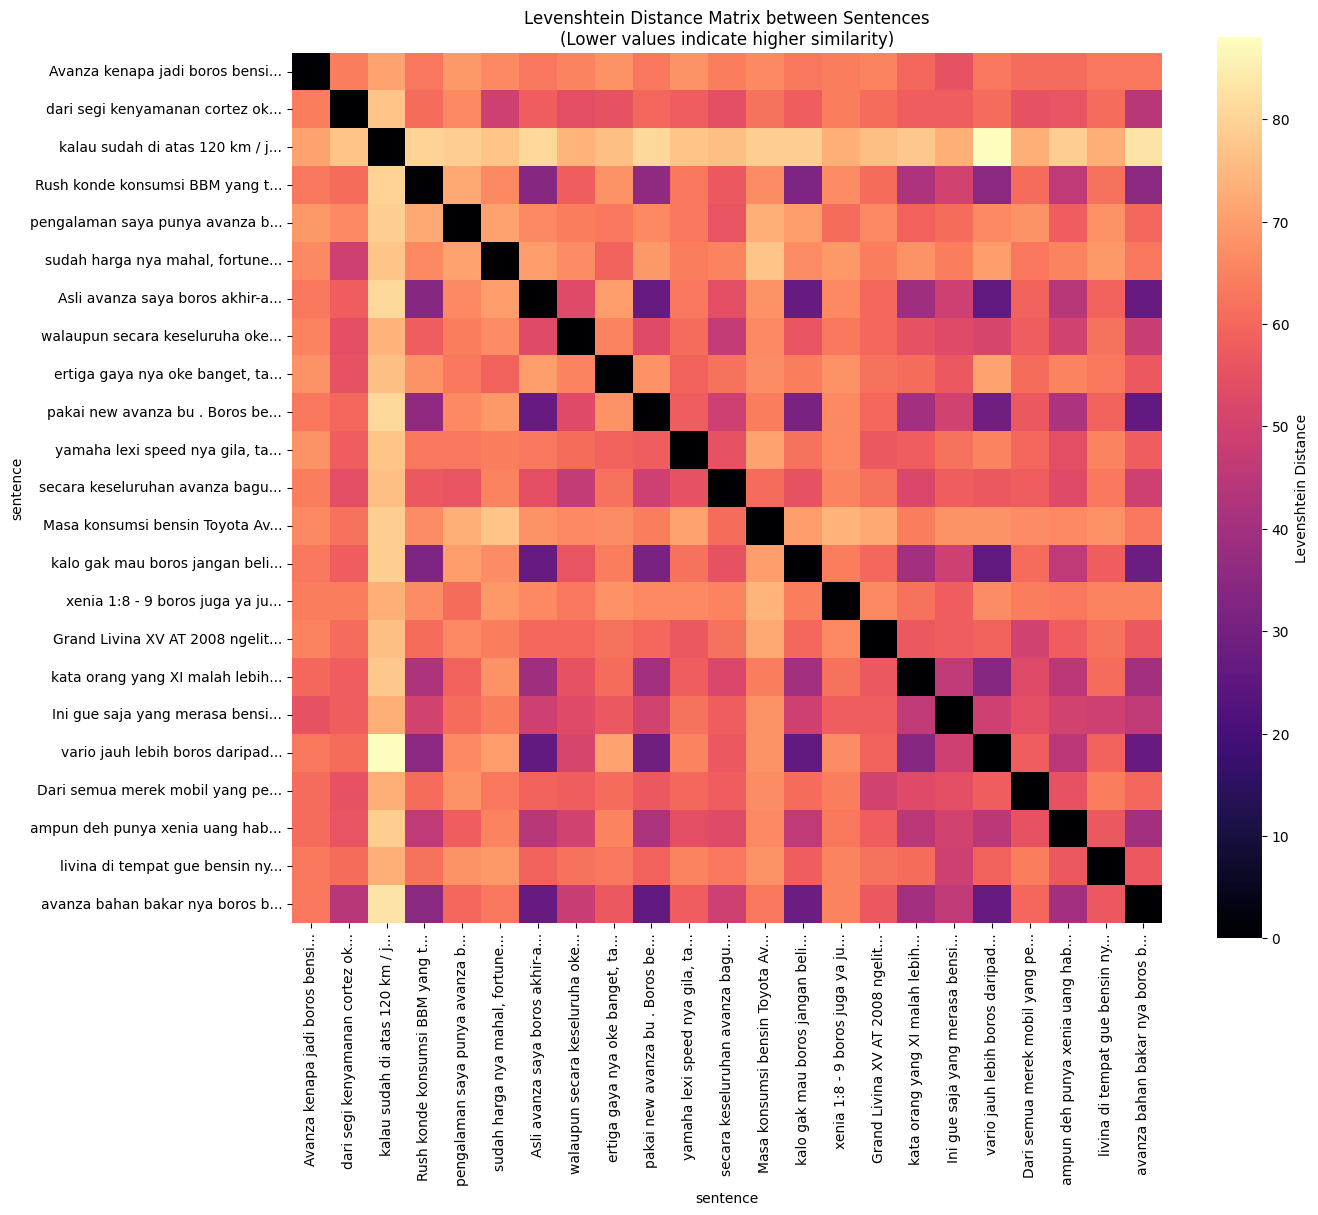


Most Similar Sentences Based on Levenshtein Distance

Query Sentence: Avanza kenapa jadi boros bensin begini dah ah. Baru diisi su...
--------------------------------------------------------------------------------
  1. Similar: Ini gue saja yang merasa bensin Xenia boros banget apa meman...
     Levenshtein Distance: 55.000000
  2. Similar: kata orang yang XI malah lebih irit dari yang LI nih ....
     Levenshtein Distance: 60.000000
  3. Similar: Dari semua merek mobil yang pernah saya pakai , terios baru ...
     Levenshtein Distance: 61.000000
  4. Similar: ampun deh punya xenia uang habis cuma buat konsumsi bensin...
     Levenshtein Distance: 61.000000
  5. Similar: Rush konde konsumsi BBM yang tetap irit ....
     Levenshtein Distance: 63.000000

Query Sentence: dari segi kenyamanan cortez oke lah, tapi bahan bakar nya it...
--------------------------------------------------------------------------------
  1. Similar: avanza bahan bakar nya boros banget...
     Levenshtein Dist

In [22]:
import Levenshtein as lev
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

# Calculate Levenshtein distances between all pairs of sentences
n_sentences = len(negative_fuel_df)
levenshtein_matrix = np.zeros((n_sentences, n_sentences))
sentences = negative_fuel_df['sentence'].values
for i in range(n_sentences):
    for j in range(n_sentences):
        levenshtein_matrix[i, j] = lev.distance(sentences[i], sentences[j])
# Create DataFrame for visualization
levenshtein_df = pd.DataFrame(
    levenshtein_matrix,
    index=negative_fuel_df['sentence'].str[:30] + '...',
    columns=negative_fuel_df['sentence'].str[:30] + '...'
)
# Plot the Levenshtein distance matrix
plt.figure(figsize=(14, 12))
sns.heatmap(levenshtein_df, cmap='magma', square=True, cbar_kws={'label': 'Levenshtein Distance'})
plt.title('Levenshtein Distance Matrix between Sentences\n(Lower values indicate higher similarity)')
plt.tight_layout()
plt.show()
def most_similar_sentences_levenshtein(levenshtein_matrix, sentences, top_n=5):
    """
    Find most similar sentences based on Levenshtein distance.
    Lower distances indicate higher similarity.
    """
    n = len(sentences)
    similar_sentences = {}
    for i in range(n):
        distances = levenshtein_matrix[i]
        # Get indices sorted by distance (ascending), excluding self-similarity
        sorted_indices = np.argsort(distances)
        # Get top N similar sentences (excluding the sentence itself at index 0)
        similar_sentences[sentences[i]] = [
            (sentences[idx], distances[idx]) 
            for idx in sorted_indices[1:top_n+1]
        ]
    return similar_sentences

## TODO: Bagaimana cara mendapatkan kalimat-kalimat yang paling mirip berdasarkan matriks Levenshtein? ##
similar_sentences_levenshtein = most_similar_sentences_levenshtein(levenshtein_matrix, sentences)


print("\n" + "="*80)
print("Most Similar Sentences Based on Levenshtein Distance")
print("="*80)
for sentence, similars in similar_sentences_levenshtein.items():
    print(f"\nQuery Sentence: {sentence[:60]}...")
    print("-" * 80)
    for i, (similar_sentence, distance) in enumerate(similars, 1):
        print(f"  {i}. Similar: {similar_sentence[:60]}...")
        print(f"     Levenshtein Distance: {distance:.6f}")